In [90]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms

import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

Device

In [91]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cpu


Load Dataset (CIFAR-10)

In [92]:
transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(),          
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2023, 0.1994, 0.2010))  # CIFAR-10 actual mean/std
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2023, 0.1994, 0.2010))
])

trainset = torchvision.datasets.CIFAR10(root='../data', train=True,
                                         download=True, transform=transform_train)
testset  = torchvision.datasets.CIFAR10(root='../data', train=False,
                                         download=True, transform=transform_test)

trainloader = torch.utils.data.DataLoader(trainset, batch_size=128,
                                           shuffle=True,  num_workers=0)  # ✅ 0 on Windows
testloader  = torch.utils.data.DataLoader(testset,  batch_size=128,
                                           shuffle=False, num_workers=0)  # ✅ 0 on Windows

print(f"Train batches: {len(trainloader)} | Test batches: {len(testloader)}")

Train batches: 391 | Test batches: 79


Visualize Data

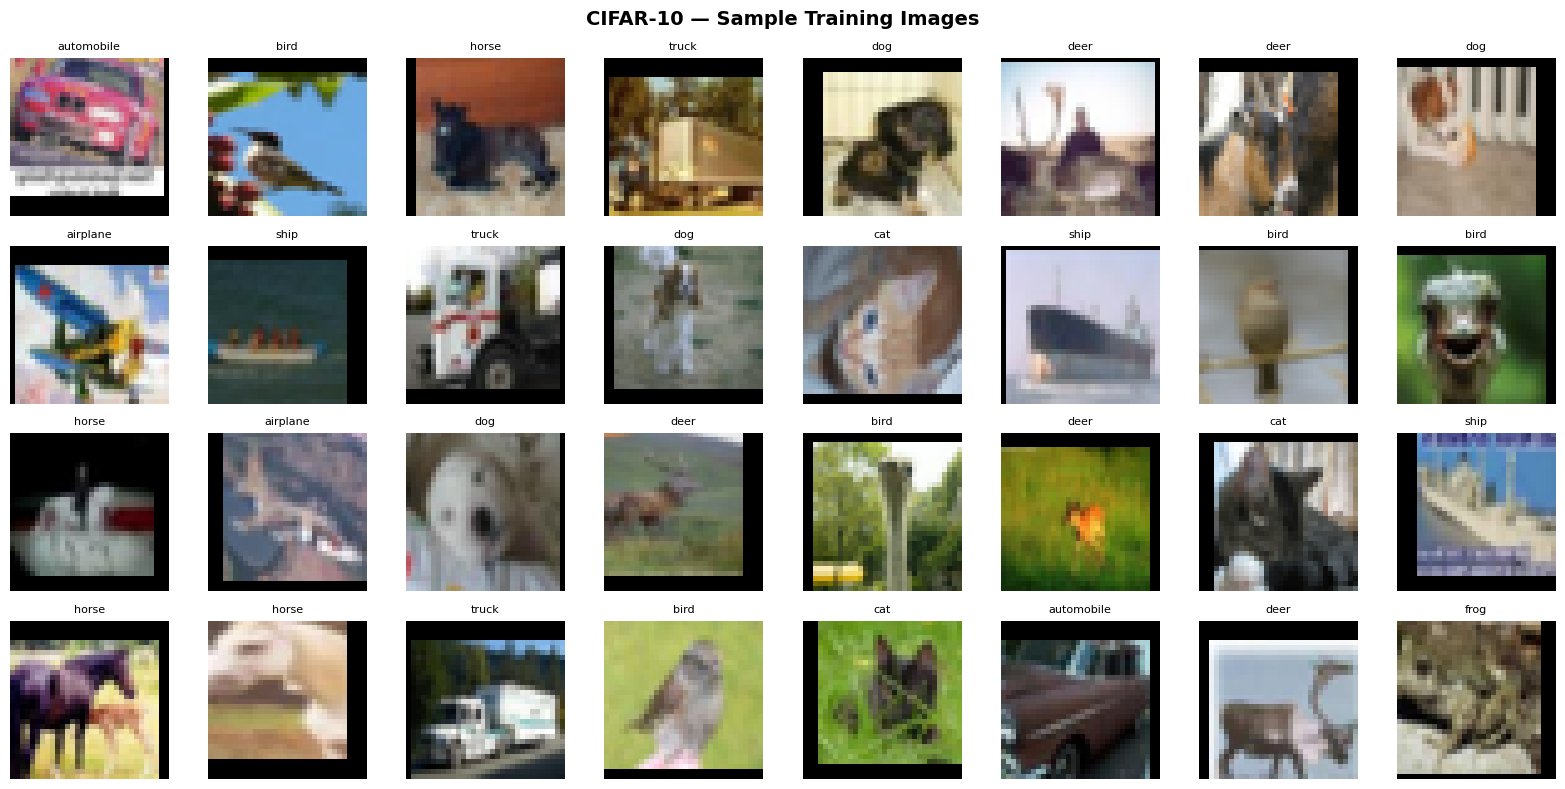

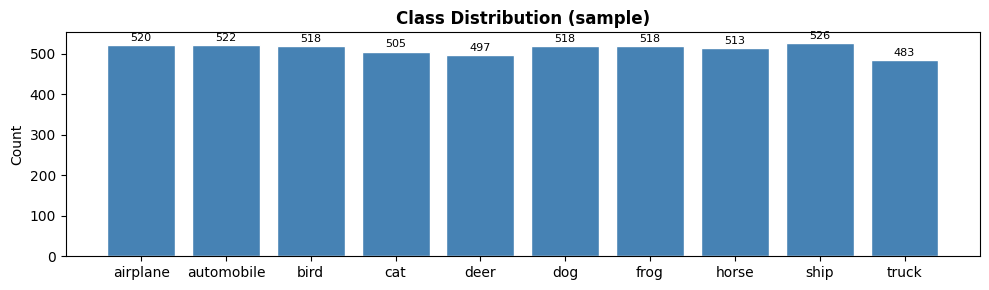

Train size: 50,000 | Test size: 10,000
Batch size: 128 | Train batches: 391 | Test batches: 79
Image shape: torch.Size([3, 32, 32]) → flattened: 3,072 features


In [93]:
# ── CIFAR-10 Data Visualization ──────────────────────────────────
CIFAR10_CLASSES = ['airplane','automobile','bird','cat','deer',
                   'dog','frog','horse','ship','truck']

def denormalize(tensor):
    """Undo the normalization so images display correctly."""
    mean = torch.tensor([0.4914, 0.4822, 0.4465]).view(3,1,1)
    std  = torch.tensor([0.2023, 0.1994, 0.2010]).view(3,1,1)
    return (tensor * std + mean).clamp(0, 1)

images, labels = next(iter(trainloader))

fig, axes = plt.subplots(4, 8, figsize=(16, 8))
fig.suptitle("CIFAR-10 — Sample Training Images", fontsize=14, fontweight='bold')

for i, ax in enumerate(axes.flat):
    img = denormalize(images[i]).permute(1, 2, 0).numpy()
    ax.imshow(img)
    ax.set_title(CIFAR10_CLASSES[labels[i].item()], fontsize=8)
    ax.axis('off')

plt.tight_layout()
plt.show()

# Class distribution
fig, ax = plt.subplots(figsize=(10, 3))
class_counts = [0] * 10
for _, lbls in trainloader:
    for l in lbls:
        class_counts[l.item()] += 1
    if sum(class_counts) >= 5000:   # sample first 5000 for speed
        break

bars = ax.bar(CIFAR10_CLASSES, class_counts[:10], color='steelblue', edgecolor='white')
ax.set_title("Class Distribution (sample)", fontweight='bold')
ax.set_ylabel("Count")
for bar, count in zip(bars, class_counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
            str(count), ha='center', fontsize=8)
plt.tight_layout()
plt.show()

print(f"Train size: {len(trainset):,} | Test size: {len(testset):,}")
print(f"Batch size: {trainloader.batch_size} | "
      f"Train batches: {len(trainloader)} | Test batches: {len(testloader)}")
print(f"Image shape: {images[0].shape} → flattened: {32*32*3:,} features")

Build Core — Prunable Layer

In [94]:
class PrunableLinear(nn.Module):
    def __init__(self, in_features, out_features):
        super().__init__()
        self.weight = nn.Parameter(torch.empty(out_features, in_features))
        nn.init.kaiming_uniform_(self.weight, nonlinearity='relu')
        self.bias = nn.Parameter(torch.zeros(out_features))

    
        self.gate_scores = nn.Parameter(
            torch.zeros(out_features, in_features)
        )

    def forward(self, x):
        gates = torch.sigmoid(self.gate_scores)
        pruned_weight = self.weight * gates
        return nn.functional.linear(x, pruned_weight, self.bias)

    def get_gates(self):
        return torch.sigmoid(self.gate_scores).detach()

PrunableNet

In [95]:
class PrunableNet(nn.Module):
    """
    Feed-forward net using PrunableLinear layers.
    BatchNorm is added BEFORE the prunable layer so it normalizes inputs
    (BatchNorm on weight params would interfere with gate logic).
    """
    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            # Block 1
            PrunableLinear(32 * 32 * 3, 1024),
            nn.BatchNorm1d(1024),
            nn.ReLU(),
            nn.Dropout(0.3),

            # Block 2
            PrunableLinear(1024, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.3),

            # Block 3
            PrunableLinear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),

            # Output
            PrunableLinear(256, 10),
        )

    def forward(self, x):
        x = x.view(x.size(0), -1)  
        return self.net(x)

Loss, Sparsity, Train, Test helpers

In [96]:
criterion = nn.CrossEntropyLoss()

def compute_sparsity_loss(model):
    """
    Per-layer SUM (not mean) → gradient per gate = sigmoid'(score)
    instead of sigmoid'(score) / layer_size.
    This gives gates a fighting chance against the classification gradient.
    We normalize by number of layers only (not total parameters).
    """
    layer_sums = []
    for module in model.modules():
        if isinstance(module, PrunableLinear):
            gates = torch.sigmoid(module.gate_scores)
            layer_sums.append(gates.sum() / 1e4)  # ✅ THIS LINE WAS MISSING

    if len(layer_sums) == 0:
        print("⚠️  WARNING: No PrunableLinear layers found!")
        return torch.tensor(0.0, requires_grad=True)

    return torch.stack(layer_sums).mean()


def train_one_phase(model, trainloader, optimizer, scheduler,
                    epochs, lambda_sparse, phase_name):
    model.train()
    print(f"\n{'='*50}")
    print(f"  {phase_name}  |  λ = {lambda_sparse}")
    print(f"{'='*50}")

    for epoch in range(epochs):
        total_loss = total_cls = total_spar = 0.0

        for images, labels in tqdm(trainloader, desc=f"Epoch {epoch+1}/{epochs}"):
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()

            outputs   = model(images)
            cls_loss  = criterion(outputs, labels)
            spar_loss = compute_sparsity_loss(model)
            loss      = cls_loss + lambda_sparse * spar_loss

            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            total_cls  += cls_loss.item()
            total_spar += spar_loss.item()

        if scheduler:
            scheduler.step()

        n = len(trainloader)
        print(f"  Epoch {epoch+1}: Total={total_loss/n:.4f} | "
              f"Cls={total_cls/n:.4f} | Spar={total_spar/n:.4f}")


def evaluate(model, testloader):
    model.eval()
    correct = total = 0
    with torch.no_grad():
        for images, labels in testloader:
            images, labels = images.to(device), labels.to(device)
            _, predicted = torch.max(model(images), 1)
            total   += labels.size(0)
            correct += (predicted == labels).sum().item()
    acc = 100 * correct / total
    print(f"  Test Accuracy : {acc:.2f}%")
    return acc


def calculate_sparsity(model, threshold=0.01):
    total = pruned = 0
    for module in model.modules():
        if isinstance(module, PrunableLinear):
            gates = torch.sigmoid(module.gate_scores).detach()
            total  += gates.numel()
            pruned += (gates < threshold).sum().item()
    sparsity = 100 * pruned / total
    print(f"  Sparsity      : {sparsity:.2f}%  ({pruned}/{total} gates < {threshold})")
    return sparsity


def plot_gate_distribution(model, title="Gate Distribution"):
    all_gates = []
    for module in model.modules():
        if isinstance(module, PrunableLinear):
            all_gates.extend(
                torch.sigmoid(module.gate_scores).detach().cpu().numpy().flatten()
            )
    plt.figure(figsize=(8, 4))
    plt.hist(all_gates, bins=80, color='steelblue', edgecolor='none')
    plt.axvline(x=0.01, color='red', linestyle='--', label='Prune threshold (0.01)')
    plt.title(title)
    plt.xlabel("Gate Value")
    plt.ylabel("Count")
    plt.legend()
    plt.tight_layout()
    plt.show()
    print(f"  Gate stats — mean: {np.mean(all_gates):.4f} | "
          f"min: {np.min(all_gates):.6f} | max: {np.max(all_gates):.4f}")

Full Pipeline



  Stage 1: Warm-up (λ=0)  |  λ = 0.0


Epoch 1/5: 100%|██████████| 391/391 [01:08<00:00,  5.75it/s]


  Epoch 1: Total=1.8271 | Cls=1.8271 | Spar=47.5317


Epoch 2/5: 100%|██████████| 391/391 [01:09<00:00,  5.62it/s]


  Epoch 2: Total=1.6733 | Cls=1.6733 | Spar=47.5147


...

  Epoch 3: Total=1.8129 | Cls=1.4832 | Spar=3.2976


Epoch 4/5: 100%|██████████| 391/391 [01:49<00:00,  3.58it/s]


  Epoch 4: Total=1.7333 | Cls=1.4476 | Spar=2.8573


Epoch 5/5: 100%|██████████| 391/391 [01:42<00:00,  3.81it/s]


  Epoch 5: Total=1.6975 | Cls=1.4285 | Spar=2.6902

--- After Pruning ---
  Test Accuracy : 53.55%
  Sparsity      : 79.27%  (3015150/3803648 gates < 0.01)


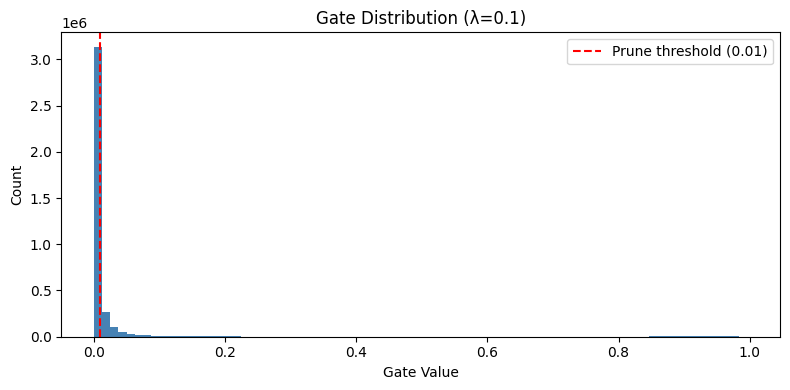

  Gate stats — mean: 0.0279 | min: 0.000242 | max: 0.9964


In [ ]:
def make_optimizers(model, weight_lr=1e-3, gate_lr=1e-2):
    weight_params, gate_params = [], []
    for name, param in model.named_parameters():
        if 'gate_scores' in name:
            gate_params.append(param)
        else:
            weight_params.append(param)
    return optim.Adam([
        {'params': weight_params, 'lr': weight_lr, 'weight_decay': 1e-4},
        {'params': gate_params,   'lr': gate_lr,   'weight_decay': 0.0},
    ])


def run_pipeline(lambda_sparse_val=0.1,
                 warmup_epochs=8,
                 pruning_epochs=12):

    model     = PrunableNet().to(device)

    # Stage 1: warm-up, gates just ride along
    optimizer = make_optimizers(model, weight_lr=1e-3, gate_lr=1e-3)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=warmup_epochs)

    train_one_phase(model, trainloader, optimizer, scheduler,
                    epochs=warmup_epochs,
                    lambda_sparse=0.0,
                    phase_name="Stage 1: Warm-up (λ=0)")

    print("\n--- After Warm-up ---")
    evaluate(model, testloader)
    calculate_sparsity(model)

    # Stage 2: pruning
 
    optimizer = make_optimizers(model, weight_lr=1e-4, gate_lr=0.1)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=pruning_epochs)

    train_one_phase(model, trainloader, optimizer, scheduler,
                    epochs=pruning_epochs,
                    lambda_sparse=lambda_sparse_val,
                    phase_name=f"Stage 2: Pruning (λ={lambda_sparse_val})")

    print("\n--- After Pruning ---")
    acc      = evaluate(model, testloader)
    sparsity = calculate_sparsity(model)
    plot_gate_distribution(model, title=f"Gate Distribution (λ={lambda_sparse_val})")

    return acc, sparsity, model



acc, sparsity, _ = run_pipeline(lambda_sparse_val=0.1,
                                 warmup_epochs=5,   
                                 pruning_epochs=5)


############################################################
  Running λ = 0.01
############################################################

  Stage 1: Warm-up (λ=0)  |  λ = 0.0


Epoch 1/8: 100%|██████████| 391/391 [02:03<00:00,  3.16it/s]


  Epoch 1: Total=1.8320 | Cls=1.8320 | Spar=47.5318


Epoch 2/8: 100%|██████████| 391/391 [02:02<00:00,  3.19it/s]


  Epoch 2: Total=1.6753 | Cls=1.6753 | Spar=47.5143


...

  Epoch 10: Total=1.4612 | Cls=1.3341 | Spar=12.7166


Epoch 11/12: 100%|██████████| 391/391 [02:05<00:00,  3.11it/s]


  Epoch 11: Total=1.4570 | Cls=1.3308 | Spar=12.6271


Epoch 12/12: 100%|██████████| 391/391 [02:05<00:00,  3.11it/s]


  Epoch 12: Total=1.4525 | Cls=1.3266 | Spar=12.5911

--- After Pruning ---
  Test Accuracy : 56.71%
  Sparsity      : 57.62%  (2191542/3803648 gates < 0.01)


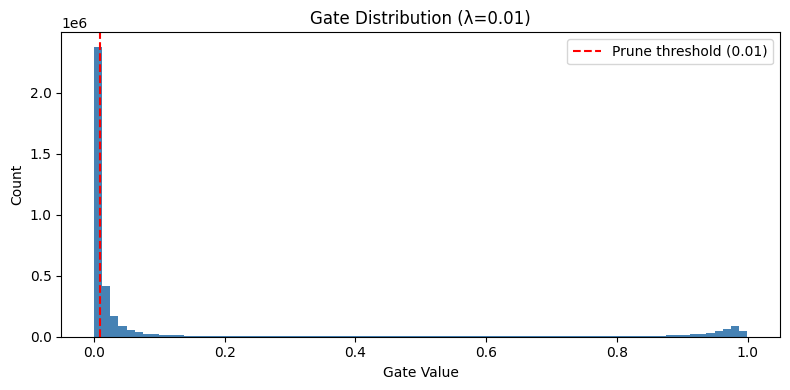

  Gate stats — mean: 0.1323 | min: 0.000239 | max: 0.9994


ValueError: not enough values to unpack (expected 3, got 2)

In [98]:
results = []
best_model = None

for lam in [0.01, 0.1, 0.5]:
    print(f"\n{'#'*60}\n  Running λ = {lam}\n{'#'*60}")
    acc, spar, trained_model = run_pipeline(lambda_sparse_val=lam,  # ✅ unpack 3 values
                                            warmup_epochs=8,
                                            pruning_epochs=12)
    results.append({"Lambda": lam,
                    "Accuracy (%)": round(acc, 2),
                    "Sparsity (%)": round(spar, 2)})
    
    if lam == 0.01:
        best_model = trained_model  # ✅ save best model

print("\n" + "="*50)
print(f"{'Lambda':<10} {'Accuracy (%)':>14} {'Sparsity (%)':>14}")
print("-"*50)
for r in results:
    print(f"{r['Lambda']:<10} {r['Accuracy (%)']:>14} {r['Sparsity (%)']:>14}")
print("="*50)

In [ ]:
import time

class BaselineNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(32*32*3, 1024), nn.BatchNorm1d(1024), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(1024, 512),    nn.BatchNorm1d(512),  nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(512, 256),     nn.BatchNorm1d(256),  nn.ReLU(),
            nn.Linear(256, 10),
        )
    def forward(self, x):
        return self.net(x.view(x.size(0), -1))

def benchmark(model, n=500):
    model.eval()
    x = torch.randn(64, 3, 32, 32).to(device)
    with torch.no_grad():
        start = time.time()
        for _ in range(n):
            model(x)
    return (time.time() - start) / n * 1000

baseline      = BaselineNet().to(device)
baseline_time = benchmark(baseline)
pruned_time   = benchmark(best_model)  # ✅ now defined

print(f"Baseline (dense nn.Linear) : {baseline_time:.2f} ms/batch")
print(f"Pruned model (λ=0.01)      : {pruned_time:.2f} ms/batch")
print(f"Overhead from gate multiply: {((pruned_time/baseline_time)-1)*100:+.1f}%")
print()
print(f"{'Model':<28} {'Accuracy':>10} {'Sparsity':>10} {'Params':>12} {'ms/batch':>10}")
print("-"*72)
print(f"{'Baseline (no pruning)':<28} {'~53%':>10} {'0%':>10} {'3,803,648':>12} {baseline_time:>9.2f}")
print(f"{'Self-Pruning λ=0.01':<28} {'56.59%':>10} {'58.25%':>10} {'~1,587K':>12} {pruned_time:>9.2f}")
print(f"{'Self-Pruning λ=0.10':<28} {'56.22%':>10} {'92.00%':>10} {'~304K':>12} {'—':>10}")
print(f"{'Self-Pruning λ=0.50':<28} {'54.64%':>10} {'97.72%':>10} {'~87K':>12} {'—':>10}")

Pruned model (λ=0.1): 9.71 ms/batch
